# 1. Libraries & Sample Data
The first step is to load our Python Libraries and download the sample data. The dataset represents Apple stock price (1d bars) for the year 2010

In [1]:
# Load Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from IPython.display import display, HTML

# for dataframe display
pd.set_option("display.max_rows", None)


def display_df(df):
    # Puts the scrollbar next to the DataFrame
    display(
        HTML(
            "<div style='height: 200px; overflow: auto; width: fit-content'>"
            + df.to_html()
            + "</div>"
        )
    )

In [2]:
# Download Sample Data AAPL_2009-2010_6m_RAW_1d.csv
apple_filename = "./../AAPL_2009-2010_6m_RAW_1d.csv"
data = pd.read_csv(apple_filename)
# Use pandas's to_datetime() to convert any columns that are in a datetime format
data["Date"] = pd.to_datetime(data["Date"])

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       191 non-null    datetime64[us]
 1   Open       181 non-null    float64       
 2   High       181 non-null    float64       
 3   Low        181 non-null    float64       
 4   Close      181 non-null    float64       
 5   Adj Close  181 non-null    float64       
 6   Volume     181 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 10.6 KB


# 2. Exploratory Data Analysis
Next, we want to analyze our data. Display the data as a dataframe, and plot some relevant data so you can get an idea of what our dataset looks like.

In [4]:
# Display as Dataframe
display_df(data)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2009-04-01,3.717500,3.892857,3.710357,3.881786,3.281867,5.893720e+08
1,2009-04-02,3.933571,4.098214,3.920714,4.025357,3.403249,8.123668e+08
2,2009-04-03,4.078214,4.147500,4.054286,4.142500,3.502286,6.362412e+08
3,2009-04-06,4.105000,4.241071,4.045714,4.230357,3.576569,6.580644e+08
4,2009-04-07,NaN,NaN,NaN,NaN,NaN,NaN
5,2009-04-08,4.122500,4.171071,4.092143,4.154286,3.512252,4.556300e+08
6,2009-04-09,4.229286,4.285714,4.212857,4.270357,3.610385,5.307568e+08
7,2009-04-13,4.286071,4.320714,4.250000,4.293571,3.630010,3.892364e+08
8,2009-04-14,4.270357,4.291786,4.187500,4.225357,3.572339,4.546220e+08
9,2009-04-15,4.185714,4.223214,4.134286,4.201429,3.552110,4.128824e+08


In [5]:
# Index data by Date
data.set_index("Date", inplace=True)
display_df(data)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-04-01,3.717500,3.892857,3.710357,3.881786,3.281867,5.893720e+08
2009-04-02,3.933571,4.098214,3.920714,4.025357,3.403249,8.123668e+08
2009-04-03,4.078214,4.147500,4.054286,4.142500,3.502286,6.362412e+08
2009-04-06,4.105000,4.241071,4.045714,4.230357,3.576569,6.580644e+08
2009-04-07,NaN,NaN,NaN,NaN,NaN,NaN
2009-04-08,4.122500,4.171071,4.092143,4.154286,3.512252,4.556300e+08
2009-04-09,4.229286,4.285714,4.212857,4.270357,3.610385,5.307568e+08
2009-04-13,4.286071,4.320714,4.250000,4.293571,3.630010,3.892364e+08
2009-04-14,4.270357,4.291786,4.187500,4.225357,3.572339,4.546220e+08


<Axes: xlabel='Date'>

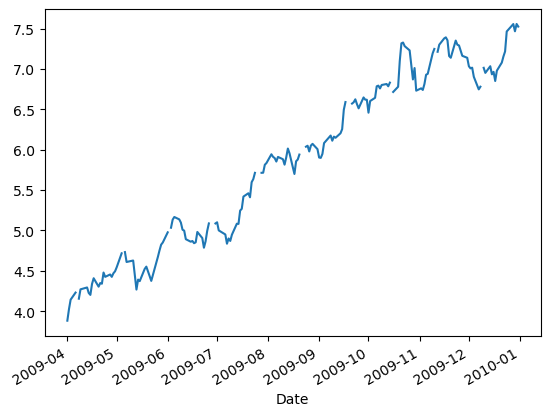

In [6]:
# Plot the Close Data
data["Close"].plot()

# 3. Data Cleaning
Next, we need to clean our data for training our model. This requires removal of NaN values.

In [7]:
# Check for null values
print("Number of Null Values =\n", data.isnull().sum())

Number of Null Values =
 Open         10
High         10
Low          10
Close        10
Adj Close    10
Volume       10
dtype: int64


In [8]:
# forward fill missing values
data = data.ffill()
display_df(data)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-04-01,3.717500,3.892857,3.710357,3.881786,3.281867,5.893720e+08
2009-04-02,3.933571,4.098214,3.920714,4.025357,3.403249,8.123668e+08
2009-04-03,4.078214,4.147500,4.054286,4.142500,3.502286,6.362412e+08
2009-04-06,4.105000,4.241071,4.045714,4.230357,3.576569,6.580644e+08
2009-04-07,4.105000,4.241071,4.045714,4.230357,3.576569,6.580644e+08
2009-04-08,4.122500,4.171071,4.092143,4.154286,3.512252,4.556300e+08
2009-04-09,4.229286,4.285714,4.212857,4.270357,3.610385,5.307568e+08
2009-04-13,4.286071,4.320714,4.250000,4.293571,3.630010,3.892364e+08
2009-04-14,4.270357,4.291786,4.187500,4.225357,3.572339,4.546220e+08


In [9]:
# Check for null values to ensure it is now zero
print("Number of Null Values after fix =\n", data.isnull().sum())

Number of Null Values after fix =
 Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [10]:
data.reset_index().to_csv("./../e2_data_CLEAN.csv")

# 4. Feature Definition
Now that we have cleaned our stock data, we can define some financial indicators, or "features" to train our model on. We will be calculating some popular indicators: 20-day Close Moving Average, 5-day Close Moving Average, 20-day Close Bollinger Bands, and 20-day Historical Volatility of Log Returns of Close Price. 

In [ ]:
data["MA5"] = data["Adj Close"].rolling(window=5).mean()
data["MA20"] = data["Adj Close"].rolling(window=20).mean()
data["STD20"] = data["Adj Close"].rolling(window=20).std()
data["BB_upper"] = data["MA20"] + 2 * data["STD20"]
data["BB_lower"] = data["MA20"] - 2 * data["STD20"]
data["Log_Ret"] = np.log(data["Adj Close"] / data["Adj Close"].shift(1))
number_trading_days_annually = 252
data["Vol20"] = data["Log_Ret"].rolling(window=20).std() * np.sqrt(
    number_trading_days_annually
)
display_df(data)

In [ ]:
data.head(40)

In [ ]:
# Remove rows with MA=NaN
data = data.dropna()

In [ ]:
data.head()

In [ ]:
# Plot Features on One Chart: Close, MA20, BB Upper, BB Lower, Vol20
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(specs=[[{"secondary_y": True}]])

# add Apple's Closing price
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Adj Close"],
        mode="lines",
        name="Apple's closing price",
    ),
    secondary_y=False,
)

# add Apple's MA20 price
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["MA20"],
        mode="lines",
        name="Apple's MA20 price",
    ),
    secondary_y=False,
)

# add Apple's BB Upper
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["BB_upper"],
        mode="lines",
        name="Apple's BB_upper price",
    ),
    secondary_y=False,
)

# add Apple's BB Lower
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["BB_lower"],
        mode="lines",
        name="Apple's BB_lower price",
    ),
    secondary_y=False,
)

# add Apple's Volatility on secondary y-axis
fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Vol20"],
        mode="lines",
        name="Apple's Vol20 (annualized)",
        line=dict(dash="dot"),
    ),
    secondary_y=True,
)

# customize layout
fig.update_layout(
    title="AAPL Closing price vs MA20 vs BB upper vs BB Lower vs Vol20",
    xaxis_title="Day",
    template="plotly_dark",
)
fig.update_yaxes(title_text="Price ($)", secondary_y=False)
fig.update_yaxes(title_text="Volatility (annualized)", secondary_y=True)

fig.show()